# Mini-Batch Gradient Descent

## Concept Explanation
Mini-Batch Gradient Descent splits the training dataset into smaller batches and performs an update for each of those batches instead of waiting for the entire dataset (Batch GD) or applying it sequentially point-by-point (Stochastic GD). 


## Expected Outcome
This approach balances the robust convergence of Batch GD with the speed of Stochastic GD. The cost history will show some slight noisiness/fluctuations compared to Batch GD, but the final regression line will successfully fit the data.

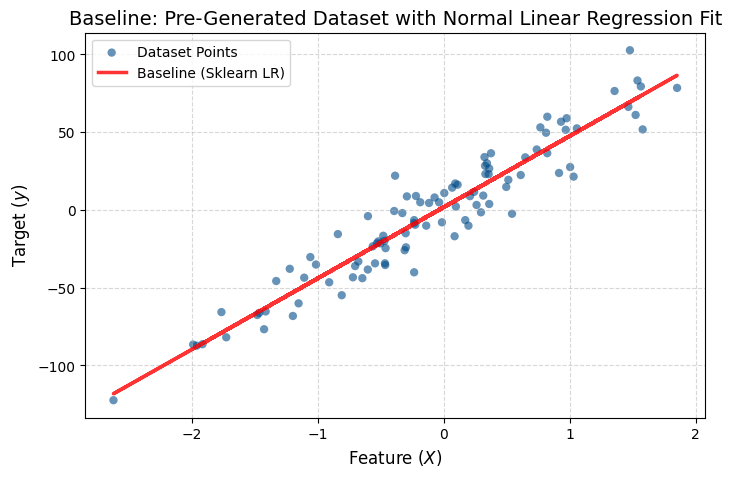

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

# 1. Generate a synthetic dataset
X, y = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)
y = y.reshape(-1, 1) # Reshape for alignment during matrix operations

# 2. Fit Simple Linear Regression (Baseline) for reference
lr = LinearRegression()
lr.fit(X, y)
y_lr_pred = lr.predict(X)

# 3. Visualization
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='#004B87', alpha=0.6, edgecolors='none', label='Dataset Points')
plt.plot(X, y_lr_pred, color='red', linewidth=2.5, alpha=0.8, label='Baseline (Sklearn LR)')
plt.title('Baseline: Pre-Generated Dataset with Normal Linear Regression Fit', fontsize=14)
plt.xlabel('Feature ($X$)', fontsize=12)
plt.ylabel('Target ($y$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Mini-Batch Gradient Descent Implementation
Here, we initialize weight and bias as zeros but set an explicit `batch_size`. We randomly shuffle the dataset at the start of each epoch and slice it into batches of that size.

We compute the error derivatives using these sub-samples. We'll store the cost sequentially to display the slightly noisy but ultimately stable convergence compared to normal Batch GD.

--- Mini-Batch Gradient Descent Metrics ---
Execution Time: 0.01569 seconds
Final Optimized Weight: 46.0215
Final Bias: 1.0481
MSE: 176.1920
MAE: 10.6635
R2 Score: 0.9066

--- Sklearn Baseline Metrics ---
MSE: 175.6221
MAE: 10.6567
R2 Score: 0.9069



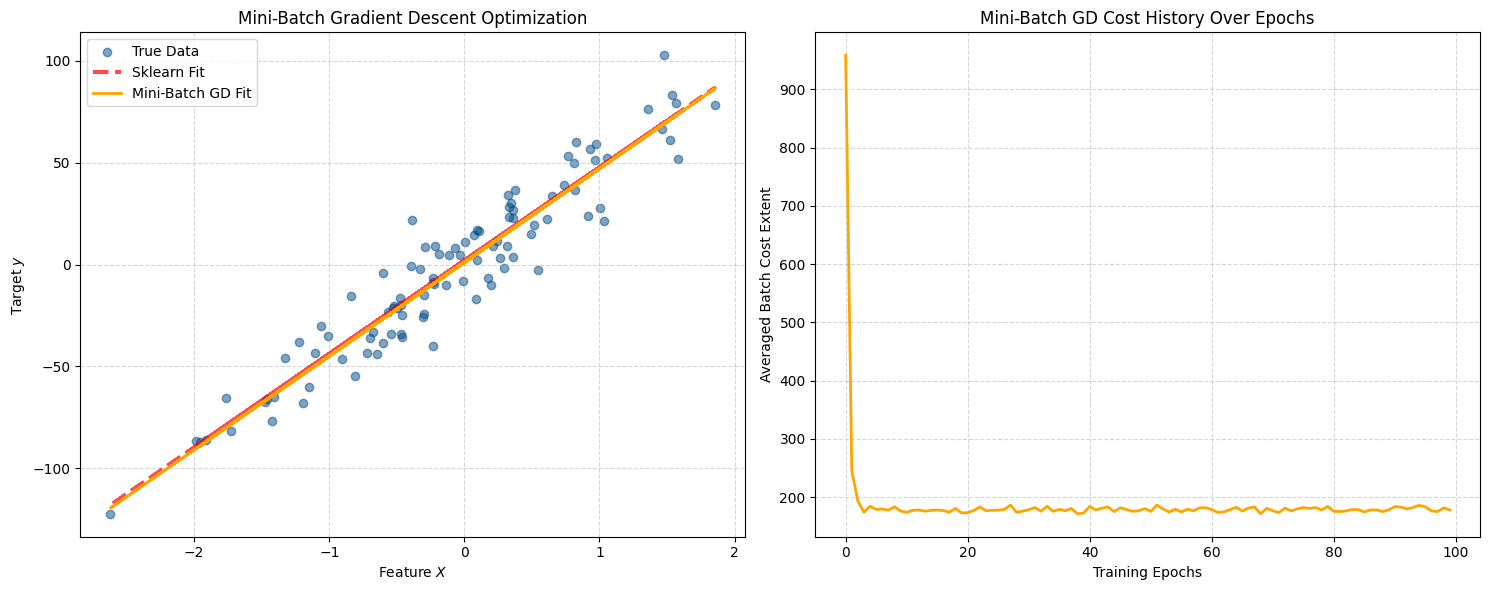

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

start_time = time.time()

# 1. Initialize explicit baseline metrics
w = np.zeros((1, 1)) 
b = np.zeros((1, 1))

learning_rate = 0.1
epochs = 100
batch_size = 15  # Specific limits splitting
n_total = len(X)
cost_history = []

for epoch in range(epochs):
    # To maintain consistency, shuffle the main set every cycle to form distinct batches 
    permutation = np.random.permutation(n_total)
    X_shuffled = X[permutation]
    y_shuffled = y[permutation]
    
    # Store temporary batch-calculated loss limits
    epoch_cost = 0
    num_batches = 0
    
    # Processing subset splits
    for i in range(0, n_total, batch_size):
        X_mini = X_shuffled[i : i + batch_size]
        y_mini = y_shuffled[i : i + batch_size]
        
        n_mini = len(X_mini)
        
        y_pred_mini = X_mini.dot(w) + b
        
        dw = (-2/n_mini) * np.sum(X_mini * (y_mini - y_pred_mini))
        db = (-2/n_mini) * np.sum(y_mini - y_pred_mini)
        
        # Incremental mini batch updates
        w -= learning_rate * dw
        b -= learning_rate * db
        
        epoch_cost += np.mean((y_mini - y_pred_mini)**2)
        num_batches += 1
        
    cost_history.append(epoch_cost / num_batches) # Store epoch's general average structure

end_time = time.time()
execution_time = end_time - start_time

final_mbgd_pred = X.dot(w) + b

print(f"--- Mini-Batch Gradient Descent Metrics ---")
print(f"Execution Time: {execution_time:.5f} seconds")
print(f"Final Optimized Weight: {float(w[0][0]):.4f}")
print(f"Final Bias: {float(b[0][0]):.4f}")
print(f"MSE: {mean_squared_error(y, final_mbgd_pred):.4f}")
print(f"MAE: {mean_absolute_error(y, final_mbgd_pred):.4f}")
print(f"R2 Score: {r2_score(y, final_mbgd_pred):.4f}\n")

print(f"--- Sklearn Baseline Metrics ---")
print(f"MSE: {mean_squared_error(y, y_lr_pred):.4f}")
print(f"MAE: {mean_absolute_error(y, y_lr_pred):.4f}")
print(f"R2 Score: {r2_score(y, y_lr_pred):.4f}\n")

# 3. Mini-Batch Comparative Representation
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].scatter(X, y, color='#004B87', alpha=0.5, label='True Data')
ax[0].plot(X, y_lr_pred, color='red', linestyle='--', linewidth=3, alpha=0.7, label='Sklearn Fit')
ax[0].plot(X, final_mbgd_pred, color='orange', linewidth=2, label='Mini-Batch GD Fit')
ax[0].set_title('Mini-Batch Gradient Descent Optimization')
ax[0].set_xlabel('Feature $X$')
ax[0].set_ylabel('Target $y$')
ax[0].legend()
ax[0].grid(True, linestyle="--", alpha=0.5)

ax[1].plot(range(epochs), cost_history, color='orange', linewidth=2)
ax[1].set_title('Mini-Batch GD Cost History Over Epochs')
ax[1].set_xlabel('Training Epochs')
ax[1].set_ylabel('Averaged Batch Cost Extent')
ax[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()